In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from imblearn.over_sampling import SMOTENC,RandomOverSampler,KMeansSMOTE
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
sns.set()

In [2]:
df = pd.read_csv('hypothyroid.csv')

In [3]:
df.shape

(3772, 30)

In [4]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,negative
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,negative
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,negative
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,negative
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,negative


In [5]:
df.isnull().sum()

age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3                           0
TT4_measured                 0
TT4                          0
T4U_measured                 0
T4U                          0
FTI_measured                 0
FTI                          0
TBG_measured                 0
TBG                          0
referral_source              0
Class                        0
dtype: int64

In [6]:
df.dtypes

age                          object
sex                          object
on_thyroxine                 object
query_on_thyroxine           object
on_antithyroid_medication    object
sick                         object
pregnant                     object
thyroid_surgery              object
I131_treatment               object
query_hypothyroid            object
query_hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH_measured                 object
TSH                          object
T3_measured                  object
T3                           object
TT4_measured                 object
TT4                          object
T4U_measured                 object
T4U                          object
FTI_measured                 object
FTI                          object
TBG_measured                 object
TBG                         

In [7]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
       'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
       'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source',
       'Class'],
      dtype='object')

In [8]:
df.describe()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
count,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,...,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772
unique,94,3,2,2,2,2,2,2,2,2,...,2,242,2,147,2,235,1,1,5,4
top,59,F,f,f,f,f,f,f,f,f,...,t,?,t,?,t,?,f,?,other,negative
freq,95,2480,3308,3722,3729,3625,3719,3719,3713,3538,...,3541,231,3385,387,3387,385,3772,3772,2201,3481


In [9]:
# There are no null values in the dataset. But this null values are replaced with '?' so we have to replace all the '?' values with nan.
for column in df.columns:
    count = df[column][df[column]=='?'].count()
    if count != 0:
        print(column, df[column][df[column]=='?'].count())
# These many column have '?' as the null value. 

age 1
sex 150
TSH 369
T3 769
TT4 231
T4U 387
FTI 385
TBG 3772


In [10]:
df['TBG'].unique()

array(['?'], dtype=object)

In [11]:
# here as per the observations TBG has only "?" so it is of no use we will be dropping it.
df = df.drop(['TBG'], axis=1)

In [12]:
df[['T4U', 'T4U_measured']]

,T4U,T4U_measured
0,1.14,t
1,?,f
2,0.91,t
3,?,f
4,0.87,t
...,...,...
3767,?,f
3768,1.08,t
3769,1.07,t
3770,0.94,t


In [13]:
df = df.drop(['TSH_measured','T3_measured','TT4_measured','T4U_measured','FTI_measured','TBG_measured'],axis =1)

In [14]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source,Class
0,41,F,f,f,f,f,f,f,f,f,...,f,f,f,1.3,2.5,125,1.14,109,SVHC,negative
1,23,F,f,f,f,f,f,f,f,f,...,f,f,f,4.1,2,102,?,?,other,negative
2,46,M,f,f,f,f,f,f,f,f,...,f,f,f,0.98,?,109,0.91,120,other,negative
3,70,F,t,f,f,f,f,f,f,f,...,f,f,f,0.16,1.9,175,?,?,other,negative
4,70,F,f,f,f,f,f,f,f,f,...,f,f,f,0.72,1.2,61,0.87,70,SVI,negative


In [15]:
#replacing all the '?' with the nan values
for column in df.columns:
    count = df[column][df[column]=='?'].count()
    if count != 0:
        df[column]=df[column].replace('?', np.nan)

In [16]:
for column in df.columns:
    count = df[column][df[column] == '?'].count()
    if count == 0:
        print(column, df[column][df[column]=='?'].count())

age 0
sex 0
on_thyroxine 0
query_on_thyroxine 0
on_antithyroid_medication 0
sick 0
pregnant 0
thyroid_surgery 0
I131_treatment 0
query_hypothyroid 0
query_hyperthyroid 0
lithium 0
goitre 0
tumor 0
hypopituitary 0
psych 0
TSH 0
T3 0
TT4 0
T4U 0
FTI 0
referral_source 0
Class 0


In [17]:
df.isnull().sum()

age                            1
sex                          150
on_thyroxine                   0
query_on_thyroxine             0
on_antithyroid_medication      0
sick                           0
pregnant                       0
thyroid_surgery                0
I131_treatment                 0
query_hypothyroid              0
query_hyperthyroid             0
lithium                        0
goitre                         0
tumor                          0
hypopituitary                  0
psych                          0
TSH                          369
T3                           769
TT4                          231
T4U                          387
FTI                          385
referral_source                0
Class                          0
dtype: int64

In [18]:
df['sex'].unique()

array(['F', 'M', nan], dtype=object)

In [19]:
df['sex']=df['sex'].map({'F':0, 'M':1})
for column in df.columns:
    if len(df[column].unique())==2:
        df[column]=df[column].map({'f':0,'m':1})

## This will map all the categorical variable to 1 and 0

In [20]:
df.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH', 'T3', 'TT4', 'T4U',
       'FTI', 'referral_source', 'Class'],
      dtype='object')

In [21]:
df['referral_source'].unique()

array(['SVHC', 'other', 'SVI', 'STMW', 'SVHD'], dtype=object)

In [22]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,tumor,hypopituitary,psych,TSH,T3,TT4,T4U,FTI,referral_source,Class
0,41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.3,2.5,125,1.14,109,SVHC,negative
1,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.1,2,102,NaN,NaN,other,negative
2,46,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.98,NaN,109,0.91,120,other,negative
3,70,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.16,1.9,175,NaN,NaN,other,negative
4,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.72,1.2,61,0.87,70,SVI,negative


In [23]:
df['referral_source'].value_counts()

other    2201
SVI      1034
SVHC      386
STMW      112
SVHD       39
Name: referral_source, dtype: int64

In [24]:
# we will use get_dummies for this one hot encoding.
df=pd.get_dummies(df,columns=['referral_source'])

In [25]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4,T4U,FTI,Class,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.5,125,1.14,109,negative,0,1,0,0,0
1,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2,102,NaN,NaN,negative,0,0,0,0,1
2,46,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,109,0.91,120,negative,0,0,0,0,1
3,70,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.9,175,NaN,NaN,negative,0,0,0,0,1
4,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.2,61,0.87,70,negative,0,0,0,1,0


In [26]:
df.shape

(3772, 27)

In [27]:
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['Class'] = label.fit_transform(df['Class'])

In [28]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4,T4U,FTI,Class,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,41,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.5,125,1.14,109,1,0,1,0,0,0
1,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2,102,NaN,NaN,1,0,0,0,0,1
2,46,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,109,0.91,120,1,0,0,0,0,1
3,70,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.9,175,NaN,NaN,1,0,0,0,0,1
4,70,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.2,61,0.87,70,1,0,0,0,1,0


In [29]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,3771,93,59,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,3622.0,NaN,NaN,NaN,0.315295,0.464698,0.0,0.0,0.0,1.0,1.0
on_thyroxine,3308.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
query_on_thyroxine,3722.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
on_antithyroid_medication,3729.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sick,3625.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pregnant,3719.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
thyroid_surgery,3719.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
I131_treatment,3713.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
query_hypothyroid,3538.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
# as per the data it looks fine. now lets start imputing the missing values 
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3, weights='uniform',missing_values=np.nan)
new_array = imputer.fit_transform(df)
new_data = pd.DataFrame(data=np.round(new_array), columns=df.columns)

In [31]:
new_data.isnull().sum()

age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3                           0
TT4                          0
T4U                          0
FTI                          0
Class                        0
referral_source_STMW         0
referral_source_SVHC         0
referral_source_SVHD         0
referral_source_SVI          0
referral_source_other        0
dtype: int64

C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

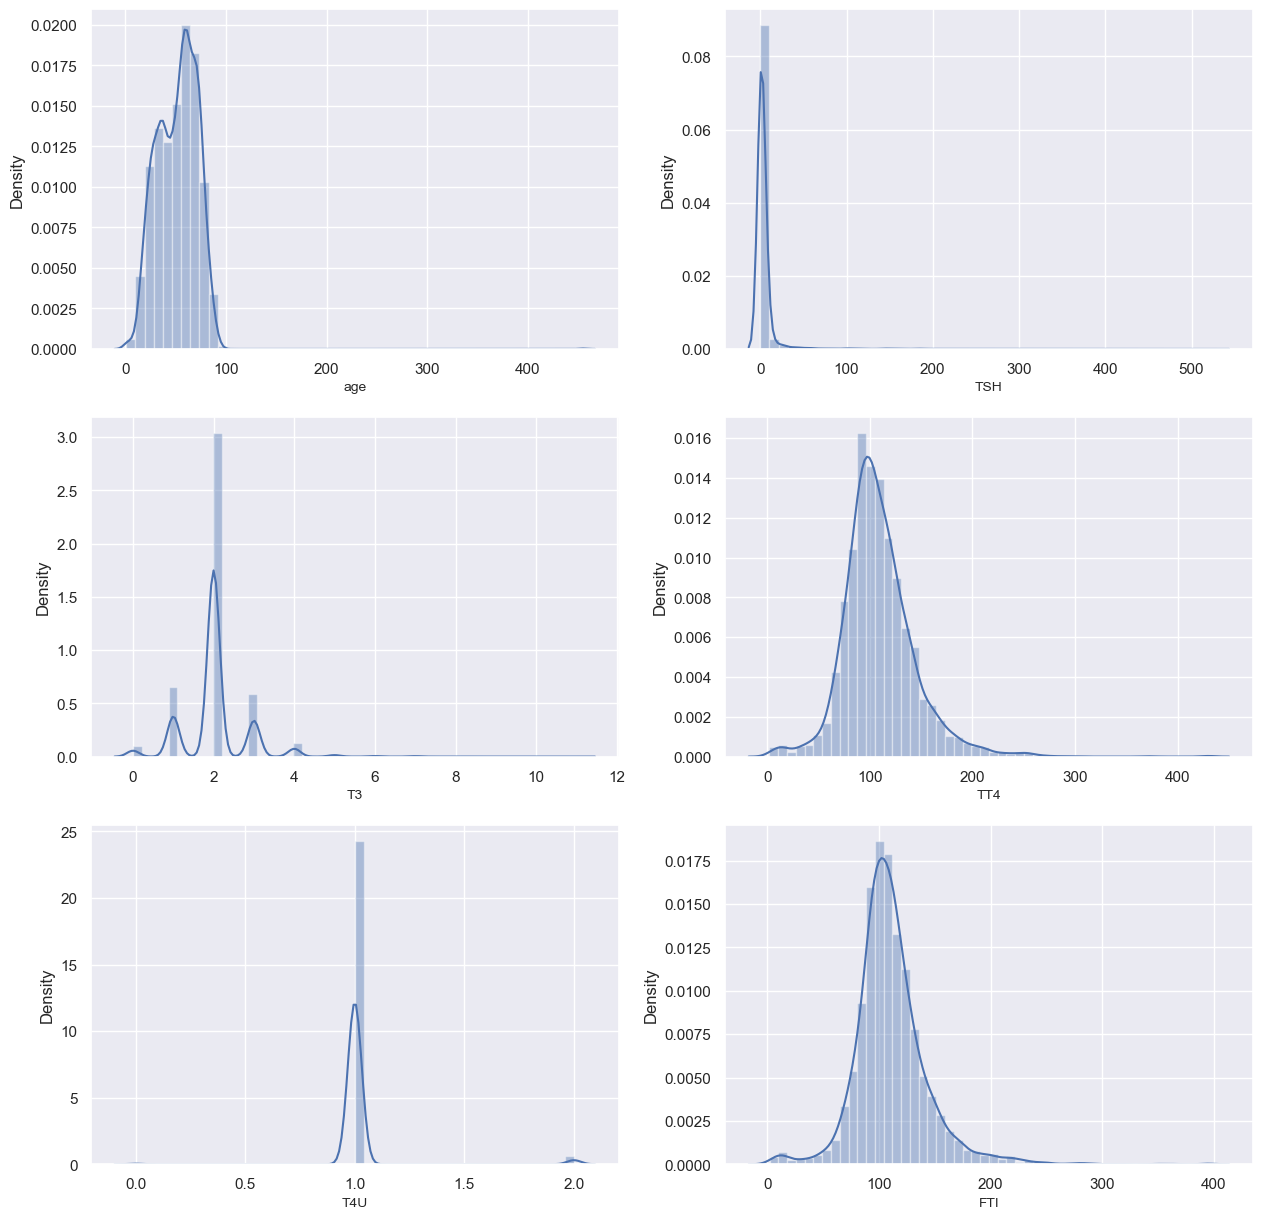

In [32]:
'''Now we don't have any missing values in the dataset.
Now let's check distrubution for continous dataset. '''
columns=['age', 'TSH', 'T3','TT4','T4U','FTI']
plt.figure(figsize=(15,15), facecolor='white')
plotnumber=1
for column in columns:
    ax = plt.subplot(3,2,plotnumber)
    sns.distplot(new_data[column])
    plt.xlabel(column,fontsize=10)
    plotnumber+=1
plt.show()

C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
C:\Users\jayes\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-lev

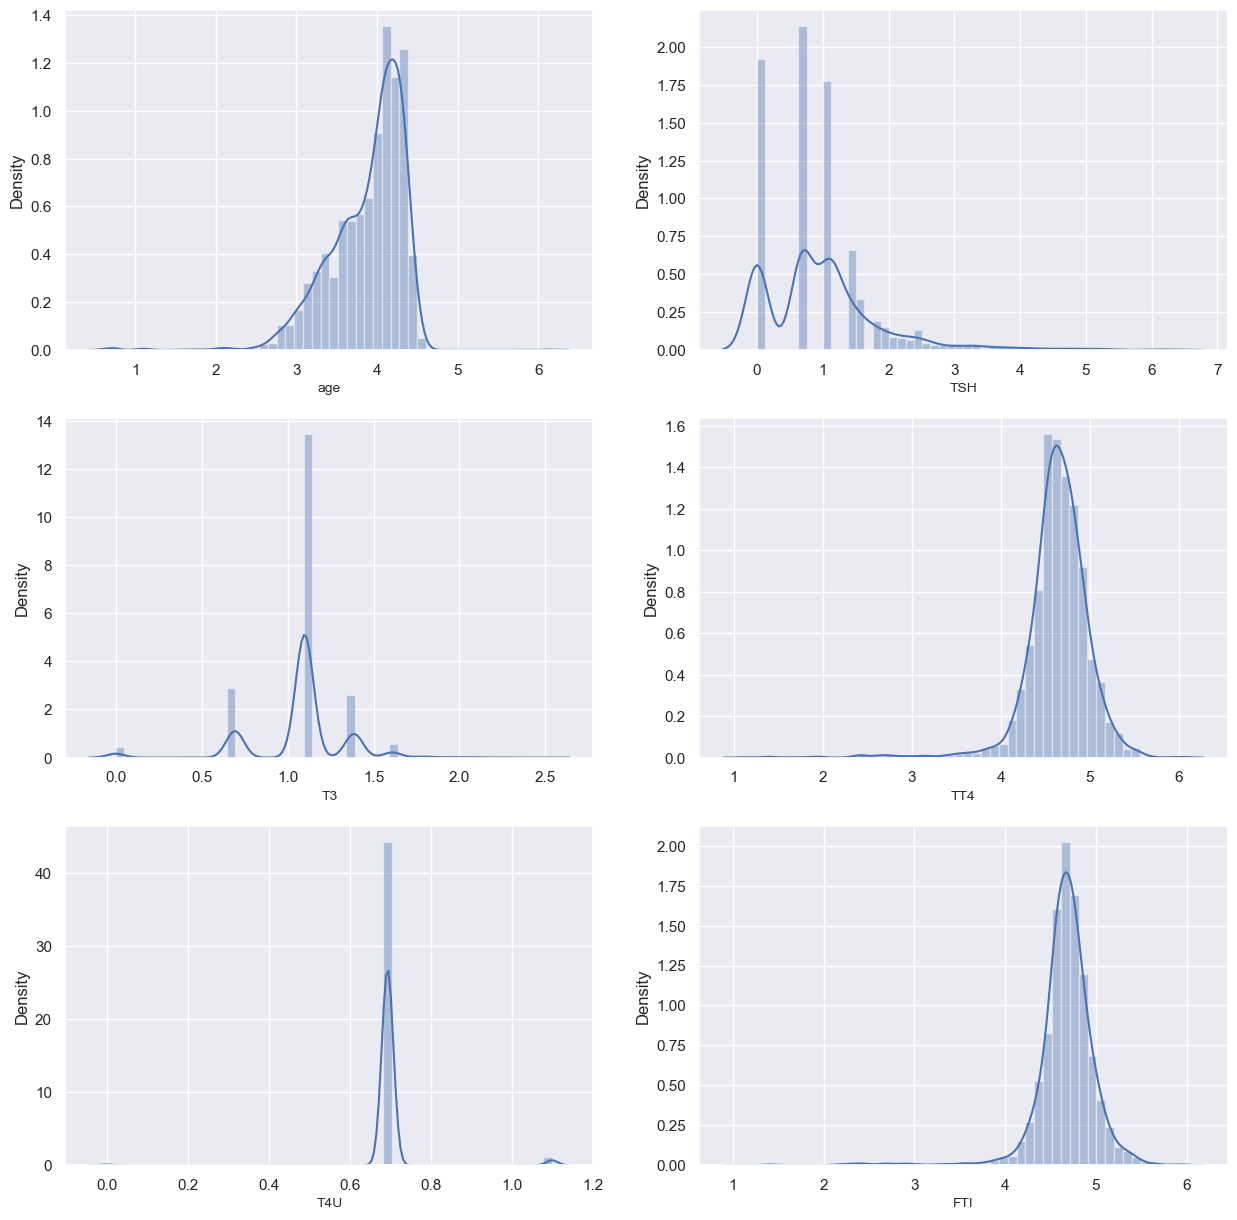

In [33]:
# some of the graphs looks perfect but some of them are left skewed inorder to handle it lets apply log transformations on to it in order to make it to the normal distrubutions.
# Before that we will add 1 to each so as to handle the log(0) exception.
columns = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
plt.figure(figsize=(15,15),facecolor='white')
plotnumber=1
for column in columns:
    new_data[column]+=1
    ax=plt.subplot(3,2,plotnumber)
    sns.distplot(np.log(new_data[column]))
    plt.xlabel(column,fontsize=10)
    plotnumber+=1
plt.show()

In [34]:
# after the log transformation all the columns are fixed but the TSH column is still showing some deflection. 
# Let us drop this column. 
new_data = new_data.drop(['TSH'], axis=1)

In [35]:
new_data.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4,T4U,FTI,Class,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,126.0,2.0,110.0,1.0,0.0,1.0,0.0,0.0,0.0
1,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,103.0,2.0,109.0,1.0,0.0,0.0,0.0,0.0,1.0
2,47.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,110.0,2.0,121.0,1.0,0.0,0.0,0.0,0.0,1.0
3,71.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,176.0,2.0,178.0,1.0,0.0,0.0,0.0,0.0,1.0
4,71.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,62.0,2.0,71.0,1.0,0.0,0.0,0.0,1.0,0.0


C:\Users\jayes\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Class', ylabel='count'>

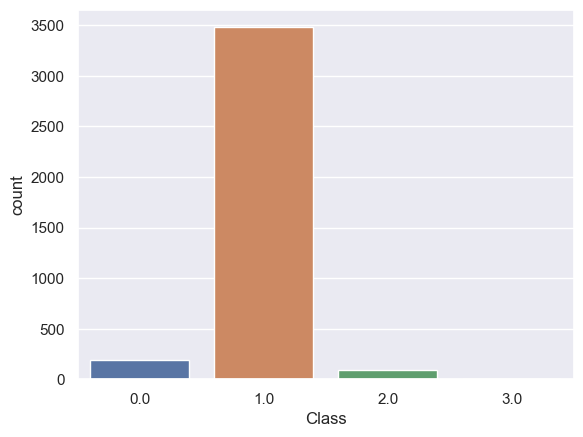

In [36]:
sns.countplot(new_data['Class'])

In [37]:
new_data.Class.unique()

array([1., 0., 2., 3.])

In [38]:
x = new_data.drop(['Class'],axis=1)
y = new_data['Class']

In [39]:
from imblearn.over_sampling import RandomOverSampler
# Create the oversampler
ros = RandomOverSampler(random_state=0)
# Fit and transform the oversampler on the data
x_resampled, y_resampled = ros.fit_resample(x, y)

In [40]:
x_resampled.shape

(13924, 25)

In [41]:
x_resampled = pd.DataFrame(data=x_resampled, columns=x.columns)

In [42]:
x_resampled.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,psych,T3,TT4,T4U,FTI,referral_source_STMW,referral_source_SVHC,referral_source_SVHD,referral_source_SVI,referral_source_other
0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,126.0,2.0,110.0,0.0,1.0,0.0,0.0,0.0
1,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,103.0,2.0,109.0,0.0,0.0,0.0,0.0,1.0
2,47.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,110.0,2.0,121.0,0.0,0.0,0.0,0.0,1.0
3,71.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,3.0,176.0,2.0,178.0,0.0,0.0,0.0,0.0,1.0
4,71.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,62.0,2.0,71.0,0.0,0.0,0.0,1.0,0.0


In [43]:
x_resampled.columns

Index(['age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych', 'T3', 'TT4', 'T4U', 'FTI',
       'referral_source_STMW', 'referral_source_SVHC', 'referral_source_SVHD',
       'referral_source_SVI', 'referral_source_other'],
      dtype='object')

In [44]:
for column in x_resampled:
    print(x_resampled[column].max(), x_resampled[column].min())

456.0 2.0
1.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
12.0 1.0
431.0 3.0
3.0 1.0
396.0 3.0
1.0 0.0
1.0 0.0
1.0 0.0
1.0 0.0
1.0 0.0


In [45]:
# dropping the columns containing all zeros. 
to_drop = ['on_thyroxine', 'query_on_thyroxine',
       'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
       'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
       'goitre', 'tumor', 'hypopituitary', 'psych']

for column in to_drop:
    print(x_resampled[column].max(), x_resampled[column].max())

0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0
0.0 0.0


In [46]:
x_resampled.drop(columns=to_drop, inplace=True)

In [47]:
# checking all the min and max values per columns to add in HTML file
for column in x_resampled:
    print(column, ": ", x_resampled[column].max(), x_resampled[column].min())

age :  456.0 2.0
sex :  1.0 0.0
T3 :  12.0 1.0
TT4 :  431.0 3.0
T4U :  3.0 1.0
FTI :  396.0 3.0
referral_source_STMW :  1.0 0.0
referral_source_SVHC :  1.0 0.0
referral_source_SVHD :  1.0 0.0
referral_source_SVI :  1.0 0.0
referral_source_other :  1.0 0.0


C:\Users\jayes\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Class', ylabel='count'>

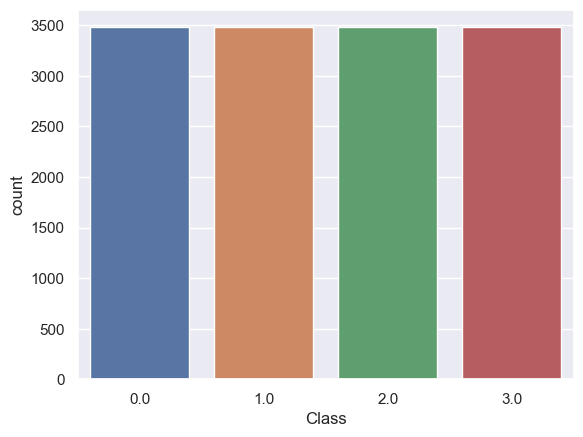

In [48]:
sns.countplot(y_resampled)

<AxesSubplot:xlabel='Class', ylabel='count'>

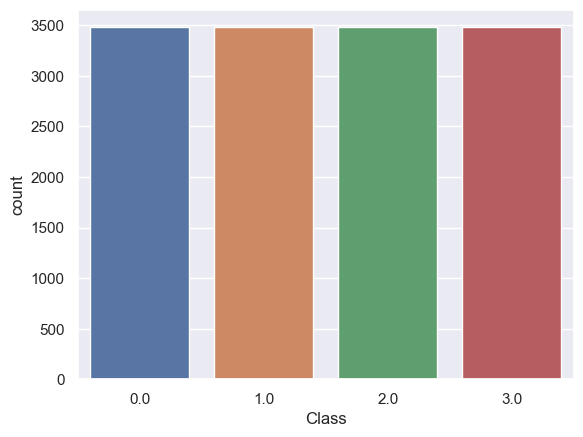

In [49]:
sns.countplot(x = y_resampled)

In [50]:
## Splitting the data into the training and testing data.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10443, 11)
(10443,)
(3481, 11)
(3481,)


In [51]:
## building the model 
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier()
random_forest_model.fit(X_train, y_train)

RandomForestClassifier()

In [52]:
y_pred = random_forest_model.predict(X_test)

In [53]:
y_pred

array([3., 2., 3., ..., 2., 1., 3.])

In [54]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_pred)

array([[897,   0,   0,   0],
       [ 23, 831,   5,   0],
       [  0,   0, 855,   0],
       [  0,   0,   0, 870]], dtype=int64)

In [55]:
from sklearn.metrics import accuracy_score
print(f'The testing accuracy for the random forest is: {round(accuracy_score(y_test, y_pred), 4)*100}%')

The testing accuracy for the random forest is: 99.2%


In [56]:
random_forest_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [57]:
## Importing the model
import pickle
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(random_forest_model, file)